In [ ]:
# ============================================
# REAL-TIME HONEYPOT DATA CLEANING (ROBUST)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

file_path = "/content/dionaeaClean2.csv"

# ============================================
# STEP 1: MANUAL SAFE PARSING
# ============================================

clean_rows = []

with open(file_path, "r") as f:
    for line in f:
        parts = line.strip().split(",")

        # Keep only rows with exactly 7 columns
        if len(parts) == 7:
            clean_rows.append(parts)

# Convert to DataFrame
df = pd.DataFrame(clean_rows, columns=[
    "protocol",
    "transport",
    "type",
    "dst_port",
    "src_ip",
    "src_port",
    "timestamp"
])

print("Valid Rows Loaded:", df.shape)

# Remove header if duplicated
df = df[df["protocol"] != "protocol"]

print("After Header Removal:", df.shape)

# ============================================
# STEP 2: DATA CLEANING
# ============================================

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert ports
df["dst_port"] = pd.to_numeric(df["dst_port"], errors='coerce')
df["src_port"] = pd.to_numeric(df["src_port"], errors='coerce')

# Remove invalid ports
df = df[(df["dst_port"] >= 0) & (df["dst_port"] <= 65535)]

# Clean categorical columns
df["protocol"] = df["protocol"].str.lower().str.strip()
df["transport"] = df["transport"].str.lower().str.strip()
df["type"] = df["type"].str.lower().str.strip()

# Convert timestamp safely
df["timestamp"] = pd.to_datetime(df["timestamp"], errors='coerce')

# If timestamp mostly invalid → generate synthetic timeline
if df["timestamp"].isna().sum() > 0.7 * len(df):
    print("Timestamp corrupted — generating synthetic timeline.")
    df["timestamp"] = pd.date_range(start="2024-01-01", periods=len(df), freq="S")

print("After Cleaning Shape:", df.shape)

# ============================================
# STEP 3: FEATURE ENGINEERING
# ============================================

df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Aggregation Features
ip_attempts = df.groupby("src_ip").size().reset_index(name="total_attempts")
df = df.merge(ip_attempts, on="src_ip", how="left")

unique_ports = df.groupby("src_ip")["dst_port"].nunique().reset_index(name="unique_ports")
df = df.merge(unique_ports, on="src_ip", how="left")

# ============================================
# STEP 4: ENCODING
# ============================================

le = LabelEncoder()
df["protocol_encoded"] = le.fit_transform(df["protocol"])
df["transport_encoded"] = le.fit_transform(df["transport"])
df["type_encoded"] = le.fit_transform(df["type"])

# ============================================
# STEP 5: SAFE PCA
# ============================================

features = [
    "dst_port", "src_port", "hour",
    "total_attempts", "unique_ports"
]

X = df[features].dropna()

if len(X) > 0:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    print("Explained Variance:", pca.explained_variance_ratio_)
else:
    print("Not enough data for PCA.")

# ============================================
# STEP 6: VISUALIZATIONS
# ============================================

if len(df) > 0:

    # Top Targeted Ports
    plt.figure()
    df["dst_port"].value_counts().head(10).plot(kind='bar')
    plt.title("Top 10 Targeted Ports")
    plt.show()

    # Attack Frequency by Hour
    plt.figure()
    df["hour"].value_counts().sort_index().plot(kind='line')
    plt.title("Attack Frequency by Hour")
    plt.show()

    # Top Attacker IPs
    plt.figure()
    df["src_ip"].value_counts().head(10).plot(kind='bar')
    plt.title("Top 10 Attacker IPs")
    plt.show()

    # PCA Plot
    if len(X) > 0:
        plt.figure()
        plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
        plt.title("PCA Projection")
        plt.show()

print("FINAL DATASET SHAPE:", df.shape)



Valid Rows Loaded: (1, 7)
After Header Removal: (0, 7)
After Cleaning Shape: (0, 7)
Not enough data for PCA.
FINAL DATASET SHAPE: (0, 16)


In [ ]:
file_path = "/content/dionaeaClean2.csv"

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(10):
        line = f.readline()
        print(repr(line))


'protocol, transport, type, dst_port, src_ip, src_port, timestamp\n'
'smbd, tcp, accept, 445, 62.74.213.178, 1176, 2022-05-07T15:08:48.091297,\n'
'smbd, tcp, accept, 445, 62.74.213.178, 1202, 2022-05-07T15:08:48.869184,\n'
'smbd, tcp, accept, 445, 62.74.213.178, 1255, 2022-05-07T15:08:50.198560,\n'
'smbd, tcp, accept, 445, 62.74.213.178, 1283, 2022-05-07T15:08:50.904213,\n'
'smbd, tcp, accept, 445, 62.74.213.178, 1313, 2022-05-07T15:08:51.603572,\n'
'smbd, tcp, accept, 445, 62.74.213.178, 1338, 2022-05-07T15:08:52.309051,\n'
'smbd, tcp, accept, 445, 62.74.213.178, 1379, 2022-05-07T15:08:53.698220,\n'
'smbd, tcp, accept, 445, 62.74.213.178, 1420, 2022-05-07T15:08:54.440758,\n'
'smbd, tcp, accept, 445, 62.74.213.178, 1458, 2022-05-07T15:08:55.224204,\n'


Raw Shape: (27529, 7)
  protocol transport    type  dst_port         src_ip  src_port  \
0     smbd       tcp  accept       445  62.74.213.178      1176   
1     smbd       tcp  accept       445  62.74.213.178      1202   
2     smbd       tcp  accept       445  62.74.213.178      1255   
3     smbd       tcp  accept       445  62.74.213.178      1283   
4     smbd       tcp  accept       445  62.74.213.178      1313   

                    timestamp  
0  2022-05-07T15:08:48.091297  
1  2022-05-07T15:08:48.869184  
2  2022-05-07T15:08:50.198560  
3  2022-05-07T15:08:50.904213  
4  2022-05-07T15:08:51.603572  
After Structure Fix:
  protocol transport    type  dst_port         src_ip  src_port  \
0     smbd       tcp  accept       445  62.74.213.178      1176   
1     smbd       tcp  accept       445  62.74.213.178      1202   
2     smbd       tcp  accept       445  62.74.213.178      1255   
3     smbd       tcp  accept       445  62.74.213.178      1283   
4     smbd       tcp  accep

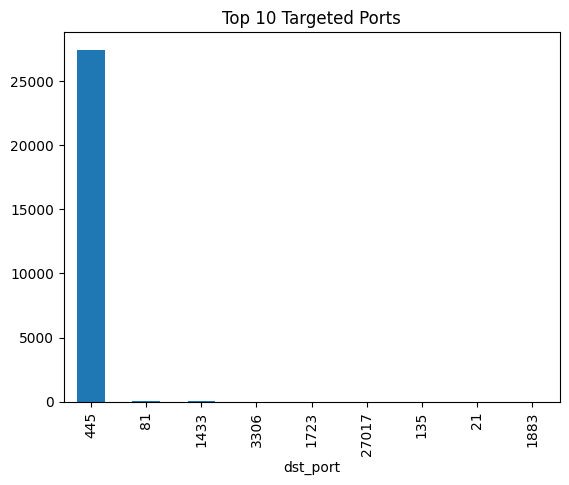

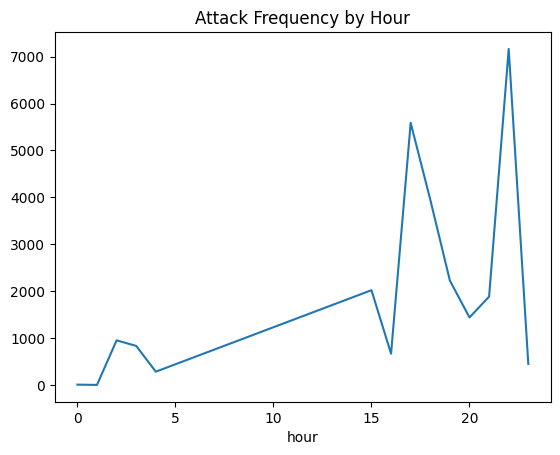

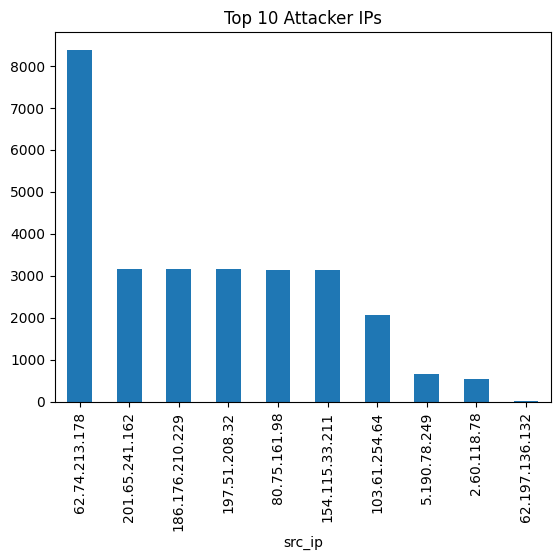

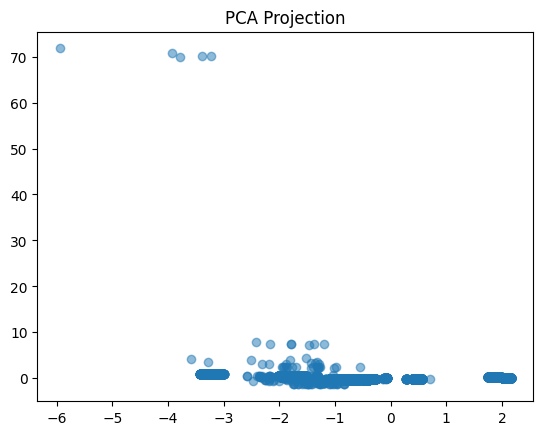

FINAL DATASET SHAPE: (27529, 16)


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

file_path = "/content/dionaeaClean2.csv"

# Load without automatic index
df = pd.read_csv(
    file_path,
    sep=",",
    skipinitialspace=True,
    on_bad_lines='skip',
    index_col=False
)

print("Raw Shape:", df.shape)
print(df.head())

# STEP 1: Fix Column Misalignment

# Reset index in case first column was used incorrectly
df.reset_index(drop=True, inplace=True)

# If timestamp column is empty but src_port contains timestamp
if df["timestamp"].isna().all():
    print("Fixing shifted columns...")

    # Move columns correctly
    df["timestamp"] = df["src_port"]
    df["src_port"] = df["src_ip"]
    df["src_ip"] = df["dst_port"]
    df["dst_port"] = df["type"]
    df["type"] = df["transport"]
    df["transport"] = df["protocol"]

print("After Structure Fix:")
print(df.head())

# STEP 2: Cleaning

df.drop_duplicates(inplace=True)

# Convert numeric safely
df["dst_port"] = pd.to_numeric(df["dst_port"], errors='coerce')
df["src_port"] = pd.to_numeric(df["src_port"], errors='coerce')

df = df[(df["dst_port"] >= 0) & (df["dst_port"] <= 65535)]

# Ensure string columns are string type before .str
df["protocol"] = df["protocol"].astype(str).str.lower().str.strip()
df["transport"] = df["transport"].astype(str).str.lower().str.strip()
df["type"] = df["type"].astype(str).str.lower().str.strip()

# Fix timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"], errors='coerce')

print("After Cleaning Shape:", df.shape)

# STEP 3: Feature Engineering

df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

ip_attempts = df.groupby("src_ip").size().reset_index(name="total_attempts")
df = df.merge(ip_attempts, on="src_ip", how="left")

unique_ports = df.groupby("src_ip")["dst_port"].nunique().reset_index(name="unique_ports")
df = df.merge(unique_ports, on="src_ip", how="left")

# STEP 4: Encoding

le = LabelEncoder()

df["protocol_encoded"] = le.fit_transform(df["protocol"])
df["transport_encoded"] = le.fit_transform(df["transport"])
df["type_encoded"] = le.fit_transform(df["type"])

# STEP 5: PCA

features = [
    "dst_port", "src_port", "hour",
    "total_attempts", "unique_ports"
]

X = df[features].dropna()

if len(X) > 0:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    print("Explained Variance:", pca.explained_variance_ratio_)
else:
    print("Not enough data for PCA.")

# STEP 6: Visualizations

plt.figure()
df["dst_port"].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Targeted Ports")
plt.show()

plt.figure()
df["hour"].value_counts().sort_index().plot(kind='line')
plt.title("Attack Frequency by Hour")
plt.show()

plt.figure()
df["src_ip"].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Attacker IPs")
plt.show()

if len(X) > 0:
    plt.figure()
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
    plt.title("PCA Projection")
    plt.show()

print("FINAL DATASET SHAPE:", df.shape)

